<a href="https://colab.research.google.com/github/samikshanimje/SmartECG-HD/blob/main/notebooks/04_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import importlib

PROJECT_ROOT="/content/drive/MyDrive/SmartECG-HD"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0,PROJECT_ROOT)

from src.config import *

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder

In [ ]:
model = load_model(BEST_MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
beats=np.load(BEATS_PATH)["beats"]

labels=np.load(LABELS_PATH)

encoder=LabelEncoder()

y=encoder.fit_transform(labels)

X=beats.reshape((-1,300,1))

In [ ]:
pred=model.predict(X)

pred=np.argmax(pred,axis=1)

3419/3419 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step


In [ ]:
print(classification_report(y,pred))

              precision    recall  f1-score   support

           0       0.51      0.97      0.67       799
           1       1.00      0.97      0.98     90453
           2       0.97      0.99      0.98      8381
           3       0.66      0.97      0.79      2703
           4       0.92      0.98      0.95      7044

    accuracy                           0.97    109380
   macro avg       0.81      0.98      0.87    109380
weighted avg       0.98      0.97      0.97    109380



<Figure size 800x800 with 0 Axes>

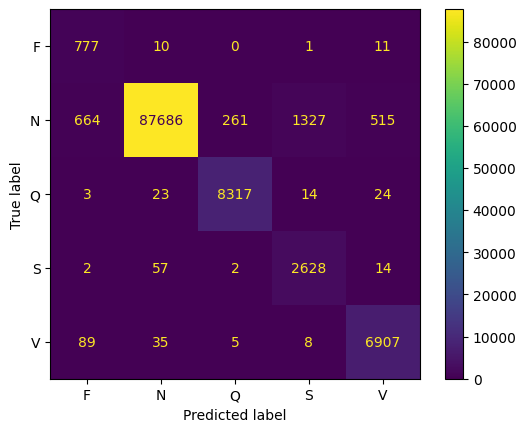

In [ ]:
cm=confusion_matrix(y,pred)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

plt.figure(figsize=(8,8))

disp.plot()

plt.show()

In [ ]:
accuracy=(pred==y).mean()*100

print(f"Accuracy : {accuracy:.2f}%")

Accuracy : 97.20%
